### Ejercicio 1 — Entorno, semilla y dispositivo

In [1]:
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print("PyTorch:", torch.__version__)
print("Dispositivo:", DEVICE)

PyTorch: 2.14.0+cpu
Dispositivo: cpu


### Ejercicio 2 — Crear e inspeccionar tensores

In [2]:

a = torch.tensor([[1, 2, 3], [4, 5, 6]], dtype=torch.float32)
b = torch.ones_like(a)

suma = a + b
producto = a * b
media_por_fila = a.mean(dim=1)

print("a =\n", a)
print("shape:", a.shape, "dtype:", a.dtype, "device:", a.device)
print("a + b =\n", suma)
print("a * b =\n", producto)
print("Media por fila:", media_por_fila)

assert a.shape == (2, 3)
assert torch.allclose(media_por_fila, torch.tensor([2.0, 5.0]))

a =
 tensor([[1., 2., 3.],
        [4., 5., 6.]])
shape: torch.Size([2, 3]) dtype: torch.float32 device: cpu
a + b =
 tensor([[2., 3., 4.],
        [5., 6., 7.]])
a * b =
 tensor([[1., 2., 3.],
        [4., 5., 6.]])
Media por fila: tensor([2., 5.])


### Ejercicio 3 — Cambiar formas y vectorizar

In [3]:
images_demo = torch.arange(2 * 1 * 8 * 8, dtype=torch.float32).reshape(2, 1, 8, 8)
flat_demo = images_demo.flatten(start_dim=1)
weights_demo = torch.randn(64, 10)
logits_demo = flat_demo @ weights_demo

print("Imágenes:", images_demo.shape)
print("Aplanadas:", flat_demo.shape)
print("Logits:", logits_demo.shape)

assert flat_demo.shape == (2, 64)
assert logits_demo.shape == (2, 10)

Imágenes: torch.Size([2, 1, 8, 8])
Aplanadas: torch.Size([2, 64])
Logits: torch.Size([2, 10])


### Ejercicio 4 — Gradientes automáticos con autograd

In [4]:
x = torch.tensor(3.0)
y_true = torch.tensor(10.0)
w = torch.tensor(2.0, requires_grad=True)
b = torch.tensor(1.0, requires_grad=True)

y_pred = w * x + b
loss = (y_pred - y_true) ** 2
loss.backward()

print("Predicción:", y_pred.item())
print("Pérdida:", loss.item())
print("dL/dw:", w.grad.item())
print("dL/db:", b.grad.item())

assert w.grad.item() == -18.0
assert b.grad.item() == -6.0

Predicción: 7.0
Pérdida: 9.0
dL/dw: -18.0
dL/db: -6.0


### Ejercicio 5 — Cargar y explorar imágenes

X: (1797, 8, 8) y: (1797,)
Rango de píxeles: 0.0 16.0
Clases: [0 1 2 3 4 5 6 7 8 9]


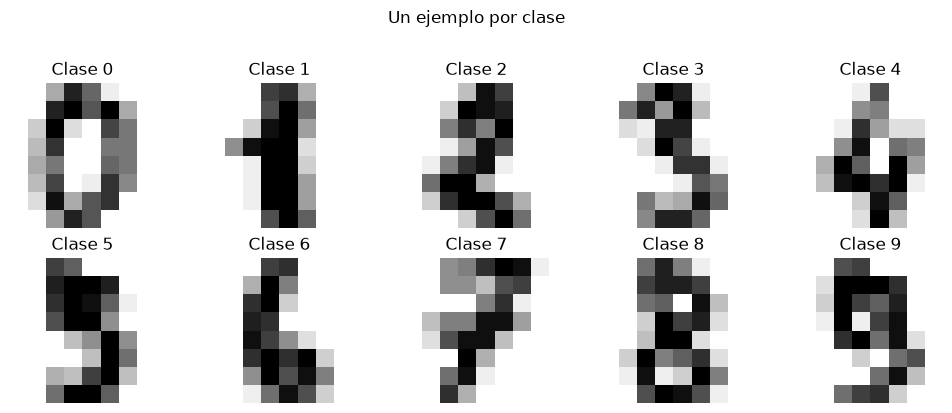

In [5]:
digits = load_digits()
X = digits.images.astype(np.float32)
y = digits.target.astype(np.int64)

print("X:", X.shape, "y:", y.shape)
print("Rango de píxeles:", X.min(), X.max())
print("Clases:", np.unique(y))

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for digit, ax in enumerate(axes.ravel()):
    idx = np.flatnonzero(y == digit)[0]
    ax.imshow(X[idx], cmap="gray_r")
    ax.set_title(f"Clase {digit}")
    ax.axis("off")
plt.suptitle("Un ejemplo por clase", y=1.02)
plt.tight_layout()
plt.show()

### Ejercicio 6 — Dividir datos y crear DataLoader

In [6]:
torch.randn(1, 3, 8, 8).unsqueeze(1).shape

torch.Size([1, 1, 3, 8, 8])

In [7]:
X_train_np, X_temp_np, y_train_np, y_temp_np = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)
X_val_np, X_test_np, y_val_np, y_test_np = train_test_split(
    X_temp_np, y_temp_np, test_size=0.50, random_state=SEED, stratify=y_temp_np
)

def to_tensors(images, labels):
    image_tensor = torch.from_numpy(images).unsqueeze(1).float() / 16.0
    label_tensor = torch.from_numpy(labels).long()
    return image_tensor, label_tensor

X_train, y_train = to_tensors(X_train_np, y_train_np)
X_val, y_val = to_tensors(X_val_np, y_val_np)
X_test, y_test = to_tensors(X_test_np, y_test_np)

train_ds = TensorDataset(X_train, y_train)
val_ds = TensorDataset(X_val, y_val)
test_ds = TensorDataset(X_test, y_test)

BATCH_SIZE = 64
generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True, generator=generator
)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

xb, yb = next(iter(train_loader))
print("Particiones:", len(train_ds), len(val_ds), len(test_ds))
print("Lote:", xb.shape, yb.shape, xb.dtype, yb.dtype)
print("Rango normalizado:", xb.min().item(), xb.max().item())

assert xb.ndim == 4 and xb.shape[1:] == (1, 8, 8)
assert yb.dtype == torch.int64

Particiones: 1257 270 270
Lote: torch.Size([64, 1, 8, 8]) torch.Size([64]) torch.float32 torch.int64
Rango normalizado: 0.0 1.0


### Ejercicio 7 — Primera capa Linear

In [8]:
flat_xb = xb.flatten(start_dim=1).to(DEVICE)
linear = nn.Linear(64, 10).to(DEVICE)
linear_logits = linear(flat_xb)
n_params_linear = sum(p.numel() for p in linear.parameters() if p.requires_grad)

print("Entrada:", flat_xb.shape)
print("Salida:", linear_logits.shape)
print("Parámetros:", n_params_linear)

assert linear_logits.shape == (xb.shape[0], 10)
assert n_params_linear == 64 * 10 + 10

Entrada: torch.Size([64, 64])
Salida: torch.Size([64, 10])
Parámetros: 650


### Ejercicio 8 — Construir una MLP

In [9]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 10),
        )

    def forward(self, x):
        return self.net(x)

mlp = MLP().to(DEVICE)
mlp_logits = mlp(xb.to(DEVICE))

print(mlp)
print("Salida:", mlp_logits.shape)
assert mlp_logits.shape == (xb.shape[0], 10)

MLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=64, out_features=64, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=10, bias=True)
  )
)
Salida: torch.Size([64, 10])


### Ejercicio 9 — Logits, probabilidades y entropía cruzada

In [10]:
probabilities = torch.softmax(mlp_logits, dim=1)
loss_fn = nn.CrossEntropyLoss()
classification_loss = loss_fn(mlp_logits, yb.to(DEVICE))

print("Suma de las primeras probabilidades:", probabilities[0].sum().item())
print("Pérdida:", classification_loss.item())

assert torch.allclose(
    probabilities.sum(dim=1),
    torch.ones(probabilities.shape[0], device=DEVICE),
    atol=1e-6,
)

Suma de las primeras probabilidades: 0.9999999403953552
Pérdida: 2.341722249984741


### Ejercicio 10 — Ejecutar un paso de optimización

In [11]:
set_seed()
demo_mlp = MLP().to(DEVICE)
optimizer = torch.optim.Adam(demo_mlp.parameters(), lr=1e-3)

demo_mlp.train()
xb_device, yb_device = xb.to(DEVICE), yb.to(DEVICE)

optimizer.zero_grad(set_to_none=True)
logits = demo_mlp(xb_device)
batch_loss = loss_fn(logits, yb_device)
batch_loss.backward()
first_grad_norm = demo_mlp.net[1].weight.grad.norm().item()
optimizer.step()

print("Pérdida del lote:", batch_loss.item())
print("Norma del gradiente:", first_grad_norm)

Pérdida del lote: 2.3299167156219482
Norma del gradiente: 0.09394346922636032


### Ejercicio 11 — Crear ciclos reutilizables de entrenamiento y evaluación

In [12]:
def run_epoch(model, loader, loss_fn, optimizer=None):
    is_training = optimizer is not None

    if is_training:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    context = torch.enable_grad() if is_training else torch.no_grad()
    with context:
        for inputs, targets in loader:
            inputs = inputs.to(DEVICE)
            targets = targets.to(DEVICE)

            if is_training:
                optimizer.zero_grad()

            logits = model(inputs)
            loss = loss_fn(logits, targets)

            if is_training:
                loss.backward()
                optimizer.step()

            batch_size = targets.size(0)
            total_loss += loss.item() * batch_size
            total_correct += (logits.argmax(dim=1) == targets).sum().item()
            total_examples += batch_size

    return {
        "loss": total_loss / total_examples,
        "accuracy": total_correct / total_examples,
    }


def fit(model, train_loader, val_loader, loss_fn, optimizer, epochs=20):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        train_metrics = run_epoch(model, train_loader, loss_fn, optimizer)
        val_metrics = run_epoch(model, val_loader, loss_fn)

        history["train_loss"].append(train_metrics["loss"])
        history["val_loss"].append(val_metrics["loss"])
        history["train_acc"].append(train_metrics["accuracy"])
        history["val_acc"].append(val_metrics["accuracy"])

        # if epoch == 1 or epoch % 5 == 0 or epoch == epochs:
        print(
            f"Época {epoch:02d}/{epochs} | "
            f"train loss={train_metrics['loss']:.4f}, acc={train_metrics['accuracy']:.3f} | "
            f"val loss={val_metrics['loss']:.4f}, acc={val_metrics['accuracy']:.3f}"
        )

    return history

### Ejercicio 12 — Entrenar la MLP y leer sus curvas

Época 01/20 | train loss=2.2840, acc=0.238 | val loss=2.2395, acc=0.326
Época 02/20 | train loss=2.1842, acc=0.293 | val loss=2.0864, acc=0.374
Época 03/20 | train loss=1.9760, acc=0.433 | val loss=1.8011, acc=0.526
Época 04/20 | train loss=1.6489, acc=0.585 | val loss=1.4401, acc=0.748
Época 05/20 | train loss=1.2854, acc=0.730 | val loss=1.1092, acc=0.793
Época 06/20 | train loss=1.0071, acc=0.792 | val loss=0.8649, acc=0.819
Época 07/20 | train loss=0.7843, acc=0.838 | val loss=0.7019, acc=0.826
Época 08/20 | train loss=0.6695, acc=0.828 | val loss=0.5880, acc=0.859
Época 09/20 | train loss=0.5782, acc=0.850 | val loss=0.5177, acc=0.852
Época 10/20 | train loss=0.5099, acc=0.860 | val loss=0.4580, acc=0.859
Época 11/20 | train loss=0.4474, acc=0.881 | val loss=0.4122, acc=0.878
Época 12/20 | train loss=0.4072, acc=0.895 | val loss=0.3784, acc=0.885
Época 13/20 | train loss=0.3524, acc=0.907 | val loss=0.3468, acc=0.904
Época 14/20 | train loss=0.3430, acc=0.898 | val loss=0.3195, ac

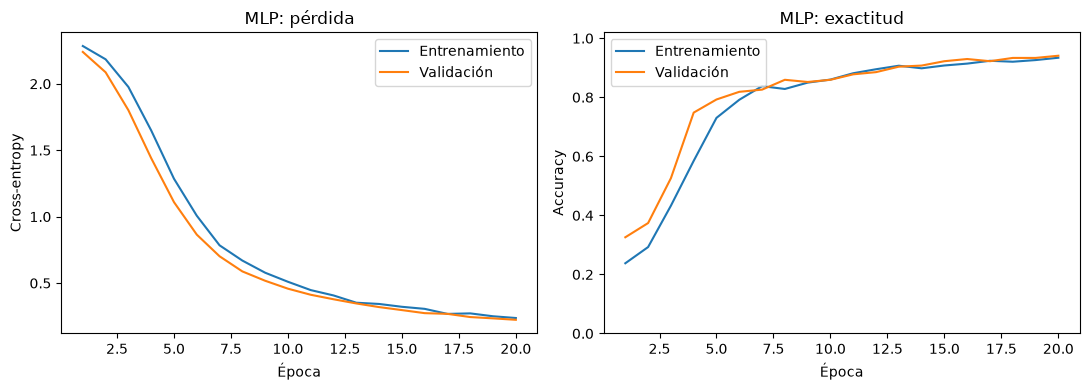

In [13]:
def plot_history(history, title):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    axes[0].plot(epochs, history["train_loss"], label="Entrenamiento")
    axes[0].plot(epochs, history["val_loss"], label="Validación")
    axes[0].set(title=f"{title}: pérdida", xlabel="Época", ylabel="Cross-entropy")
    axes[0].legend()

    axes[1].plot(epochs, history["train_acc"], label="Entrenamiento")
    axes[1].plot(epochs, history["val_acc"], label="Validación")
    axes[1].set(title=f"{title}: exactitud", xlabel="Época", ylabel="Accuracy", ylim=(0, 1.02))
    axes[1].legend()

    plt.tight_layout()
    plt.show()

set_seed()
mlp = MLP().to(DEVICE)
loss_fn = nn.CrossEntropyLoss()
mlp_optimizer = torch.optim.Adam(mlp.parameters(), lr=1e-3)
history_mlp = fit(
    mlp, train_loader, val_loader, loss_fn, mlp_optimizer, epochs=20
)

plot_history(history_mlp, "MLP")

### Ejercicio 13 — Evaluar la MLP

Métricas MLP: {'loss': 0.1717859129110972, 'accuracy': 0.9481481481481482}


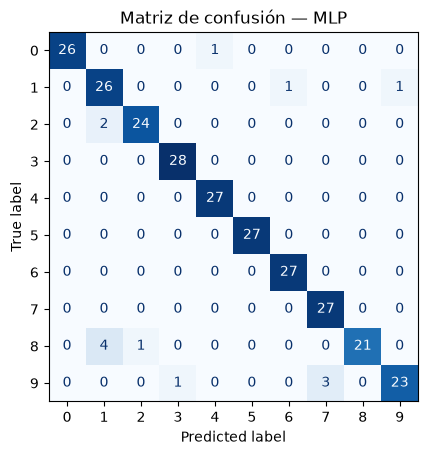

              precision    recall  f1-score   support

           0      1.000     0.963     0.981        27
           1      0.812     0.929     0.867        28
           2      0.960     0.923     0.941        26
           3      0.966     1.000     0.982        28
           4      0.964     1.000     0.982        27
           5      1.000     1.000     1.000        27
           6      0.964     1.000     0.982        27
           7      0.900     1.000     0.947        27
           8      1.000     0.808     0.894        26
           9      0.958     0.852     0.902        27

    accuracy                          0.948       270
   macro avg      0.952     0.947     0.948       270
weighted avg      0.952     0.948     0.948       270



In [14]:
def collect_predictions(model, loader):
    model.eval()
    all_targets = []
    all_predictions = []

    with torch.no_grad():
        for inputs, targets in loader:
            logits = model(inputs.to(DEVICE))
            predictions = logits.argmax(dim=1).cpu()
            all_targets.append(targets.cpu())
            all_predictions.append(predictions)

    return (
        torch.cat(all_targets).numpy(),
        torch.cat(all_predictions).numpy(),
    )

test_metrics_mlp = run_epoch(mlp, test_loader, loss_fn)
y_true_mlp, y_pred_mlp = collect_predictions(mlp, test_loader)

print("Métricas MLP:", test_metrics_mlp)
ConfusionMatrixDisplay.from_predictions(
    y_true_mlp, y_pred_mlp, cmap="Blues", colorbar=False
)
plt.title("Matriz de confusión — MLP")
plt.show()

print(classification_report(y_true_mlp, y_pred_mlp, digits=3, zero_division=0))

### Ejercicio 14 — Convolución, canales y pooling

In [15]:
sample_images = xb[:4].to(DEVICE)
conv = nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, padding=1).to(DEVICE)
pool = nn.MaxPool2d(kernel_size=2)

with torch.no_grad():
    feature_maps = torch.relu(conv(sample_images))
    pooled_maps = pool(feature_maps)

print("Entrada:", sample_images.shape)
print("Tras Conv2d:", feature_maps.shape)
print("Tras MaxPool2d:", pooled_maps.shape)

assert feature_maps.shape == (4, 8, 8, 8)
assert pooled_maps.shape == (4, 8, 4, 4)

Entrada: torch.Size([4, 1, 8, 8])
Tras Conv2d: torch.Size([4, 8, 8, 8])
Tras MaxPool2d: torch.Size([4, 8, 4, 4])


### Ejercicio 15 — Construir una CNN pequeña

In [16]:
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 2 * 2, 64),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(64, 10),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

cnn = SmallCNN().to(DEVICE)
cnn_logits = cnn(xb.to(DEVICE))

print(cnn)
print("Salida:", cnn_logits.shape)
assert cnn_logits.shape == (xb.shape[0], 10)

SmallCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=128, out_features=64, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)
Salida: torch.Size([64, 10])


### Ejercicio 16 — Entrenar y evaluar la CNN

Época 01/20 | train loss=2.2916, acc=0.111 | val loss=2.2710, acc=0.100
Época 02/20 | train loss=2.2394, acc=0.224 | val loss=2.1850, acc=0.256
Época 03/20 | train loss=2.0858, acc=0.435 | val loss=1.9441, acc=0.507
Época 04/20 | train loss=1.7143, acc=0.547 | val loss=1.4361, acc=0.707
Época 05/20 | train loss=1.2406, acc=0.686 | val loss=0.9807, acc=0.774
Época 06/20 | train loss=0.8750, acc=0.769 | val loss=0.6909, acc=0.804
Época 07/20 | train loss=0.6931, acc=0.799 | val loss=0.5678, acc=0.819
Época 08/20 | train loss=0.5550, acc=0.846 | val loss=0.4787, acc=0.852
Época 09/20 | train loss=0.4445, acc=0.871 | val loss=0.4000, acc=0.881
Época 10/20 | train loss=0.4138, acc=0.878 | val loss=0.3635, acc=0.900
Época 11/20 | train loss=0.3550, acc=0.893 | val loss=0.3185, acc=0.907
Época 12/20 | train loss=0.3123, acc=0.902 | val loss=0.3127, acc=0.904
Época 13/20 | train loss=0.2819, acc=0.920 | val loss=0.2671, acc=0.926
Época 14/20 | train loss=0.2412, acc=0.924 | val loss=0.2367, ac

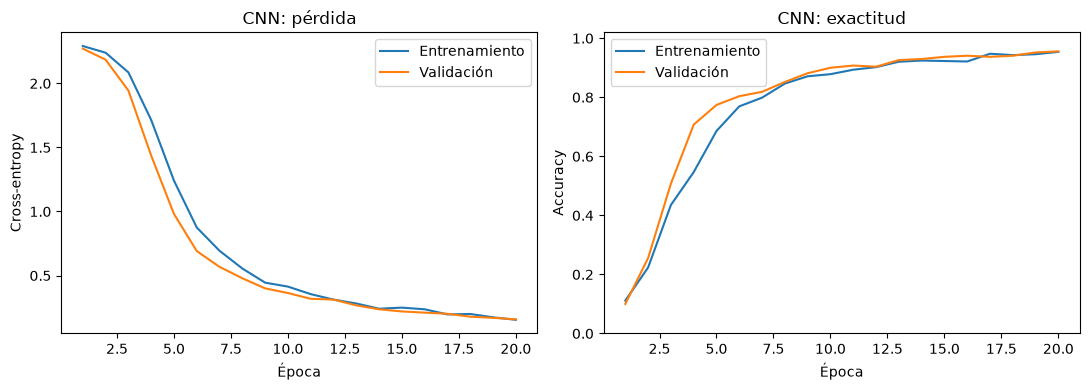

Métricas CNN: {'loss': 0.1395672702127033, 'accuracy': 0.9518518518518518}


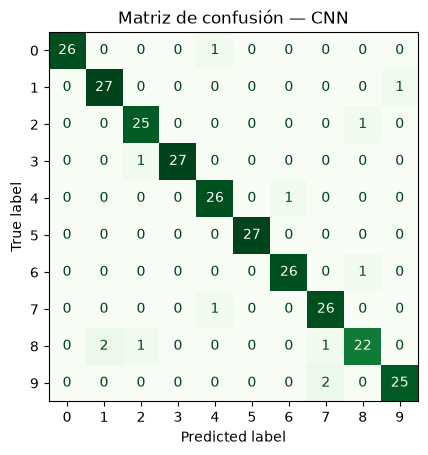

In [17]:
set_seed()
cnn = SmallCNN().to(DEVICE)
cnn_optimizer = torch.optim.Adam(cnn.parameters(), lr=1e-3)
history_cnn = fit(
    cnn, train_loader, val_loader, loss_fn, cnn_optimizer, epochs=20
)

plot_history(history_cnn, "CNN")

test_metrics_cnn = run_epoch(cnn, test_loader, loss_fn)
y_true_cnn, y_pred_cnn = collect_predictions(cnn, test_loader)

print("Métricas CNN:", test_metrics_cnn)
ConfusionMatrixDisplay.from_predictions(
    y_true_cnn, y_pred_cnn, cmap="Greens", colorbar=False
)
plt.title("Matriz de confusión — CNN")
plt.show()

### Ejercicio 17 — Comparar MLP y CNN

In [18]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

comparison = {
    "MLP": {
        "parameters": count_parameters(mlp),
        "test_loss": test_metrics_mlp["loss"],
        "test_accuracy": test_metrics_mlp["accuracy"],
    },
    "CNN": {
        "parameters": count_parameters(cnn),
        "test_loss": test_metrics_cnn["loss"],
        "test_accuracy": test_metrics_cnn["accuracy"],
    },
}

for model_name, metrics in comparison.items():
    print(
        f"{model_name:>3} | parámetros={metrics['parameters']:,} | "
        f"test loss={metrics['test_loss']:.4f} | "
        f"test acc={metrics['test_accuracy']:.3f}"
    )

MLP | parámetros=6,570 | test loss=0.1718 | test acc=0.948
CNN | parámetros=13,706 | test loss=0.1396 | test acc=0.952


### Ejercicio 18 — Guardar, recargar y analizar errores

In [19]:
cnn

SmallCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=128, out_features=64, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

Predicciones idénticas tras recargar: True
Checkpoint guardado en: D:\Users\ClientAdm\Documents\datascience-g8\01-python-intro\notebooks\cnn_digits_state_dict.pt


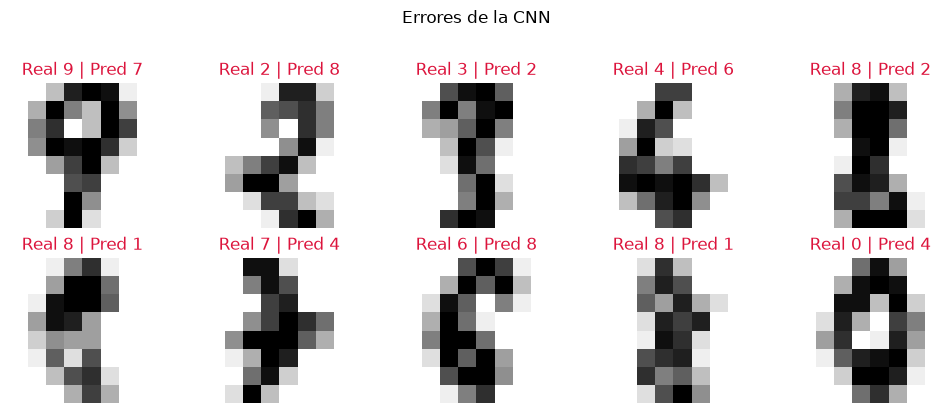

In [20]:
checkpoint_path = Path("cnn_digits_state_dict.pt")
torch.save(cnn.state_dict(), checkpoint_path)

loaded_cnn = SmallCNN().to(DEVICE)
try:
    state_dict = torch.load(checkpoint_path, map_location=DEVICE, weights_only=True)
except TypeError:  # Compatibilidad con versiones antiguas de PyTorch
    state_dict = torch.load(checkpoint_path, map_location=DEVICE)
loaded_cnn.load_state_dict(state_dict)
loaded_cnn.eval()

y_true_loaded, y_pred_loaded = collect_predictions(loaded_cnn, test_loader)
assert np.array_equal(y_true_loaded, y_true_cnn)
assert np.array_equal(y_pred_loaded, y_pred_cnn)
print("Predicciones idénticas tras recargar:", True)
print("Checkpoint guardado en:", checkpoint_path.resolve())

wrong_indices = np.flatnonzero(y_pred_cnn != y_true_cnn)
indices_to_show = wrong_indices[:10]

if len(indices_to_show) == 0:
    print("La CNN no cometió errores en este conjunto de prueba.")
else:
    fig, axes = plt.subplots(2, 5, figsize=(10, 4))
    for ax in axes.ravel():
        ax.axis("off")
    for ax, idx in zip(axes.ravel(), indices_to_show):
        ax.imshow(X_test[idx, 0].numpy(), cmap="gray_r")
        ax.set_title(f"Real {y_true_cnn[idx]} | Pred {y_pred_cnn[idx]}", color="crimson")
        ax.axis("off")
    plt.suptitle("Errores de la CNN", y=1.02)
    plt.tight_layout()
    plt.show()